**Mount Google Drive**

In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


**Load and preprocess the dataset**

In [2]:
import pandas as pd

# Replace the path below with the correct path to your IMDB dataset file
dataset_path = '/content/drive/MyDrive/IMDB Dataset/IMDB_Dataset.csv'

# Load dataset
df = pd.read_csv(dataset_path)

# Preview dataset
print("Dataset shape:", df.shape)
print(df.head())


Dataset shape: (50000, 2)
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive


**Spliting dataset into 70% training, 10% validation, and 20% testing:**

In [4]:
from sklearn.model_selection import train_test_split

# First split: 80% train_val and 20% test
train_val_texts, test_texts, train_val_labels, test_labels = train_test_split(
    df['review'], df['sentiment'], test_size=0.2, stratify=df['sentiment'], random_state=42
)

# Second split: from train_val, get 87.5% train and 12.5% val → 87.5% of 80% = 70%, 12.5% of 80% = 10%
train_texts, val_texts, train_labels, val_labels = train_test_split(
    train_val_texts, train_val_labels, test_size=0.125, stratify=train_val_labels, random_state=42
)

# Confirm split sizes
print(f"Training size: {len(train_texts)}")
print(f"Validation size: {len(val_texts)}")
print(f"Testing size: {len(test_texts)}")


Training size: 35000
Validation size: 5000
Testing size: 10000


**Build and train three models: Logistic Regression, Naive Bayes, and Random Forest using TF-IDF features.**

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder

# Encode labels (positive/negative → 1/0)
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(train_labels)
y_val = label_encoder.transform(val_labels)
y_test = label_encoder.transform(test_labels)

# TF-IDF Vectorization
vectorizer = TfidfVectorizer(max_features=5000)
X_train = vectorizer.fit_transform(train_texts)
X_val = vectorizer.transform(val_texts)
X_test = vectorizer.transform(test_texts)


**Train Models**

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
lr_val_pred = lr_model.predict(X_val)
lr_acc = accuracy_score(y_val, lr_val_pred)
print(f"Logistic Regression Validation Accuracy: {lr_acc:.4f}")

# Naive Bayes
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
nb_val_pred = nb_model.predict(X_val)
nb_acc = accuracy_score(y_val, nb_val_pred)
print(f"Naive Bayes Validation Accuracy: {nb_acc:.4f}")

# Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_val_pred = rf_model.predict(X_val)
rf_acc = accuracy_score(y_val, rf_val_pred)
print(f"Random Forest Validation Accuracy: {rf_acc:.4f}")


Logistic Regression Validation Accuracy: 0.8884
Naive Bayes Validation Accuracy: 0.8524
Random Forest Validation Accuracy: 0.8402


In [7]:
from sklearn.model_selection import GridSearchCV


**Logistic Regression Hyperparameter Tuning**

In [8]:
# Logistic Regression - Hyperparameter Grid
lr_params = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['lbfgs']
}

lr_grid = GridSearchCV(LogisticRegression(max_iter=1000), lr_params, cv=5, scoring='accuracy', n_jobs=-1)
lr_grid.fit(X_val, y_val)

print("Best Logistic Regression Params:", lr_grid.best_params_)
print("Best Logistic Regression CV Accuracy:", lr_grid.best_score_)


Best Logistic Regression Params: {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}
Best Logistic Regression CV Accuracy: 0.8577999999999999


**Naive Bayes Hyperparameter Tuning**

In [9]:
# Multinomial Naive Bayes - Hyperparameter Grid
nb_params = {
    'alpha': [0.01, 0.1, 1, 10]
}

nb_grid = GridSearchCV(MultinomialNB(), nb_params, cv=5, scoring='accuracy', n_jobs=-1)
nb_grid.fit(X_val, y_val)

print("Best Naive Bayes Params:", nb_grid.best_params_)
print("Best Naive Bayes CV Accuracy:", nb_grid.best_score_)


Best Naive Bayes Params: {'alpha': 1}
Best Naive Bayes CV Accuracy: 0.8416


**Random Forest Hyperparameter Tuning**

In [10]:
# Random Forest - Hyperparameter Grid
rf_params = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), rf_params, cv=5, scoring='accuracy', n_jobs=-1)
rf_grid.fit(X_val, y_val)

print("Best Random Forest Params:", rf_grid.best_params_)
print("Best Random Forest CV Accuracy:", rf_grid.best_score_)


Best Random Forest Params: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}
Best Random Forest CV Accuracy: 0.8192


In [11]:
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt



**Make Predictions on Test Set**

In [12]:
# Use best estimators from GridSearchCV
best_lr = lr_grid.best_estimator_
best_nb = nb_grid.best_estimator_
best_rf = rf_grid.best_estimator_

# Predict probabilities for AUC/ROC
lr_probs = best_lr.predict_proba(X_test)[:, 1]
nb_probs = best_nb.predict_proba(X_test)[:, 1]
rf_probs = best_rf.predict_proba(X_test)[:, 1]

# Predict class labels
lr_preds = best_lr.predict(X_test)
nb_preds = best_nb.predict(X_test)
rf_preds = best_rf.predict(X_test)


**Calculate Accuracy & AUC**

In [13]:
# Accuracy
print("Logistic Regression Test Accuracy:", accuracy_score(y_test, lr_preds))
print("Naive Bayes Test Accuracy:", accuracy_score(y_test, nb_preds))
print("Random Forest Test Accuracy:", accuracy_score(y_test, rf_preds))

# AUC
print("Logistic Regression AUC:", roc_auc_score(y_test, lr_probs))
print("Naive Bayes AUC:", roc_auc_score(y_test, nb_probs))
print("Random Forest AUC:", roc_auc_score(y_test, rf_probs))


Logistic Regression Test Accuracy: 0.8645
Naive Bayes Test Accuracy: 0.8433
Random Forest Test Accuracy: 0.8327
Logistic Regression AUC: 0.9397006800000001
Naive Bayes AUC: 0.92291676
Random Forest AUC: 0.9107200999999999


**Plot ROC Curves**

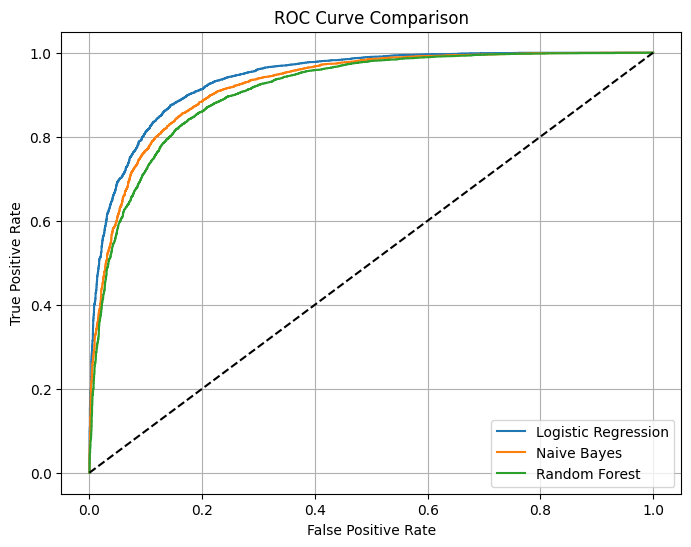

In [14]:
# Compute ROC curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_probs)
fpr_nb, tpr_nb, _ = roc_curve(y_test, nb_probs)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label='Logistic Regression')
plt.plot(fpr_nb, tpr_nb, label='Naive Bayes')
plt.plot(fpr_rf, tpr_rf, label='Random Forest')
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.grid(True)
plt.show()


 **Best-performing model**

Logistic Regression is better than the other models.


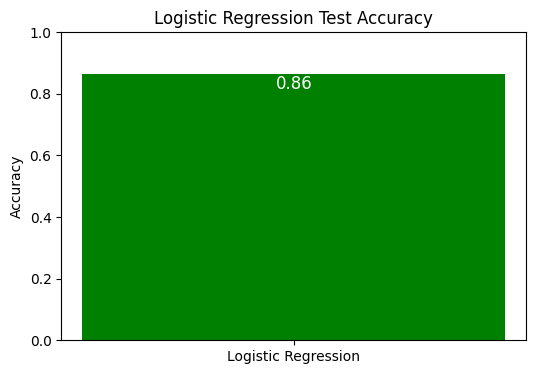

In [15]:
import matplotlib.pyplot as plt

# Selected best model (based on previous evaluation)
best_model_name = "Logistic Regression"
best_model_accuracy = accuracy_score(y_test, lr_preds)

# Print result
print(f"{best_model_name} is better than the other models.")

# Plot accuracy
plt.figure(figsize=(6, 4))
plt.bar(best_model_name, best_model_accuracy, color='green')
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title(f"{best_model_name} Test Accuracy")
plt.text(0, best_model_accuracy - 0.05, f"{best_model_accuracy:.2f}", ha='center', color='white', fontsize=12)
plt.show()
